# logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv('Flight prediction.csv')

In [3]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [5]:
columns_data=data.columns

In [6]:
columns_data

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [7]:
data.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [8]:
data.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

<Axes: >

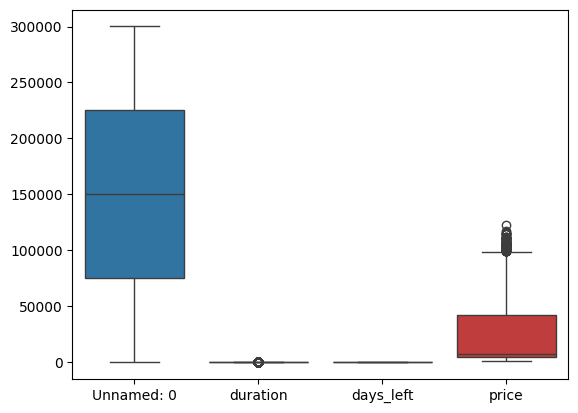

In [9]:
sns.boxplot(data=data)

In [10]:
data.sample(10)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
250854,250854,Air_India,AI-501,Bangalore,Afternoon,one,Night,Mumbai,Business,8.83,27,54684
107965,107965,Indigo,6E-6257,Bangalore,Early_Morning,one,Afternoon,Kolkata,Economy,7.17,38,5424
69834,69834,Indigo,6E-6086,Mumbai,Evening,zero,Night,Kolkata,Economy,2.75,47,4499
200173,200173,Indigo,6E-539,Chennai,Morning,one,Evening,Kolkata,Economy,8.08,25,5042
6569,6569,GO_FIRST,G8-2403,Delhi,Morning,one,Evening,Mumbai,Economy,8.00,33,5958
263566,263566,Air_India,AI-732,Kolkata,Afternoon,one,Morning,Delhi,Business,20.17,42,53743
66998,66998,Air_India,AI-774,Mumbai,Night,zero,Night,Kolkata,Economy,2.75,32,3177
275405,275405,Vistara,UK-874,Hyderabad,Morning,one,Night,Delhi,Business,12.17,14,54115
239803,239803,Air_India,AI-639,Mumbai,Morning,one,Morning,Hyderabad,Business,23.33,27,32230
282727,282727,Air_India,AI-698,Hyderabad,Night,one,Evening,Bangalore,Business,20.67,45,38043


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [12]:
columns_drop=["Unnamed: 0","flight"]
data=data.drop(columns=columns_drop,axis=1)

In [13]:
data.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
print(data.columns)

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')


In [15]:
# Encode categorical columns using label encoding to avoid high-dimensional one-hot expansion
columns_label = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in columns_label:
    data[col] = le.fit_transform(data[col].astype(str))

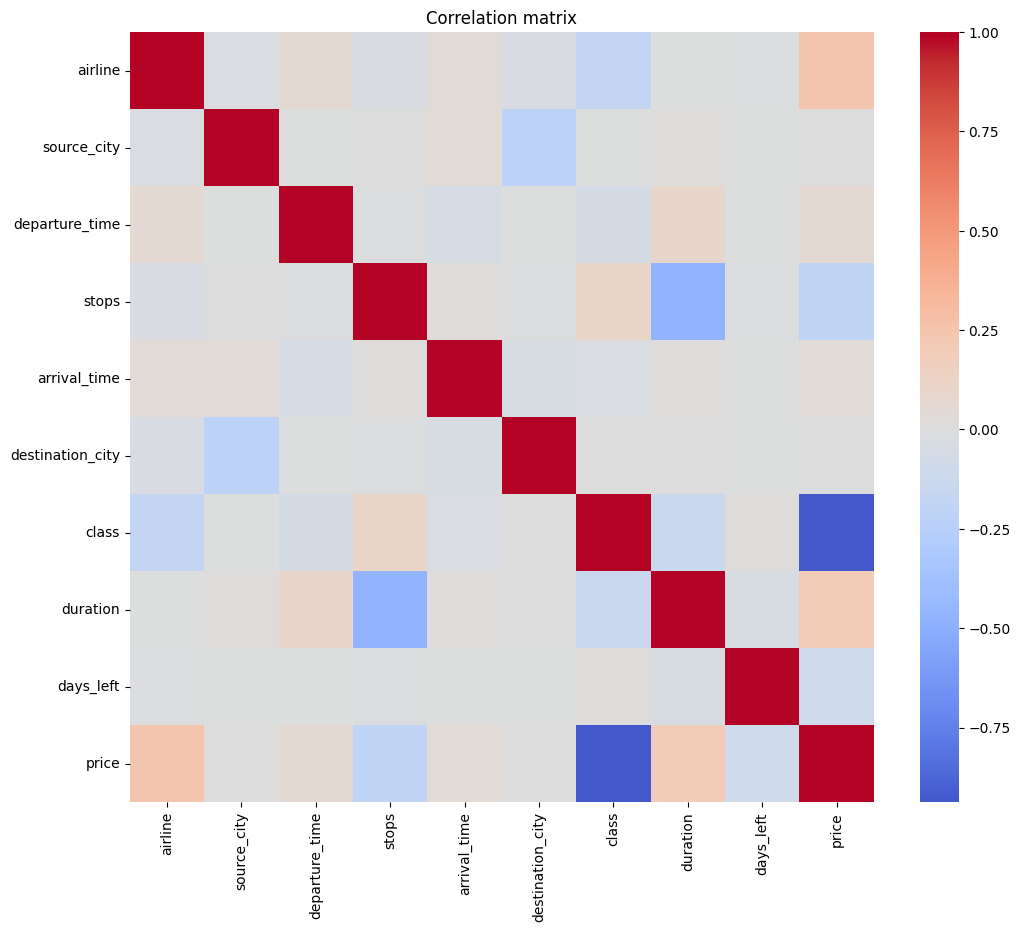

In [16]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [17]:
#train test split
X=data.drop(columns="price",axis=1)
y=data["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [18]:
# regression using LinearRegression and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


RMSE: 7014.309680483318
R2: 0.904554350718816


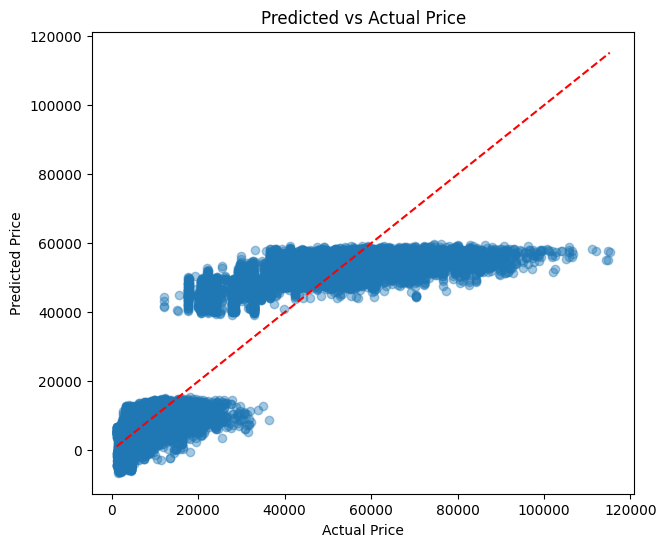

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('RMSE:', rmse)
print('R2:', r2)
# Visualization: Predicted vs Actual
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [20]:
import joblib

joblib.dump(model, "flight_price_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
